# Machine Learning  — Cane Corso пример
  
**предсказване на приблизително тегло на Cane Corso по примерни данни.**



## 1. Идея на проекта

Ще използвам основните теми от материала:

- Machine Learning basics
- Linear Regression
- Training and Testing
- Evaluating Model Performance
- Polynomial Regression
- Bias–Variance Tradeoff
- Regularization
- RANSAC
- Cross-Validation
- Hyperparameter Tuning
- Feature Engineering


## 2. Импортиране на библиотеки


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [3]:
np.random.seed(42)


## 3. Създаване на примерни данни

Ще създам синтетичен dataset с Cane Corso профили.

Колони:
- age_months — възраст в месеци
- height_cm — височина
- activity_level — активност от 1 до 5
- sex_male — 1 за мъжки, 0 за женски
- weight_kg — тегло


In [4]:
n = 180

age_months = np.random.randint(3, 84, n)
sex_male = np.random.binomial(1, 0.55, n)
activity_level = np.random.randint(1, 6, n)


In [5]:
height_cm = (
    38
    + 0.55 * age_months
    - 0.0035 * age_months**2
    + sex_male * 4
    + np.random.normal(0, 3, n)
)

height_cm = np.clip(height_cm, 38, 72)


In [6]:
weight_kg = (
    6
    + 0.58 * age_months
    - 0.0042 * age_months**2
    + 0.72 * height_cm
    + sex_male * 5
    + activity_level * 0.8
    + np.random.normal(0, 4, n)
)

weight_kg = np.clip(weight_kg, 8, 70)


In [7]:
df = pd.DataFrame({
    "age_months": age_months,
    "height_cm": height_cm.round(1),
    "activity_level": activity_level,
    "sex_male": sex_male,
    "weight_kg": weight_kg.round(1)
})

df.head()


,age_months,height_cm,activity_level,sex_male,weight_kg
0,54,61.4,5,1,70.0
1,17,45.5,5,0,49.8
2,74,64.5,3,1,70.0
3,63,60.3,4,1,70.0
4,23,54.4,2,1,66.2


In [8]:
df.describe().round(2)


,age_months,height_cm,activity_level,sex_male,weight_kg
count,180.00,180.00,180.00,180.00,180.00
mean,42.48,55.13,3.12,0.57,62.84
std,24.26,7.26,1.45,0.50,9.92
min,3.00,38.00,1.00,0.00,35.50
25%,22.25,51.65,2.00,0.00,58.15
50%,44.00,56.20,3.00,1.00,68.65
75%,64.00,60.32,4.00,1.00,70.00
max,83.00,69.10,5.00,1.00,70.00


## 4. Визуален преглед на данните

Преди да обучим модел, е добре да видим как изглеждат данните.


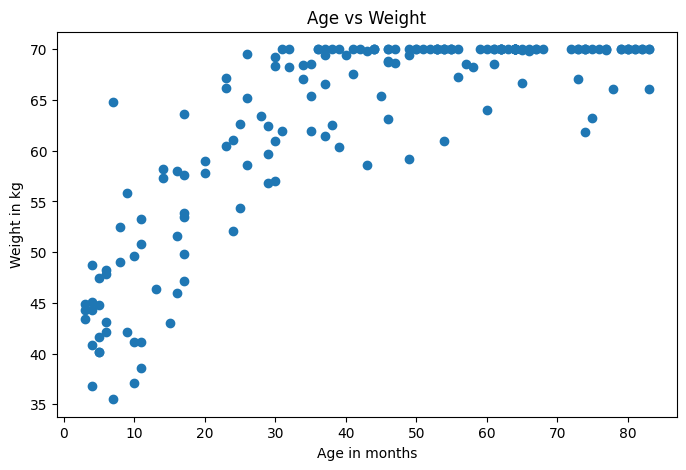

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"])
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Age vs Weight")
plt.show()


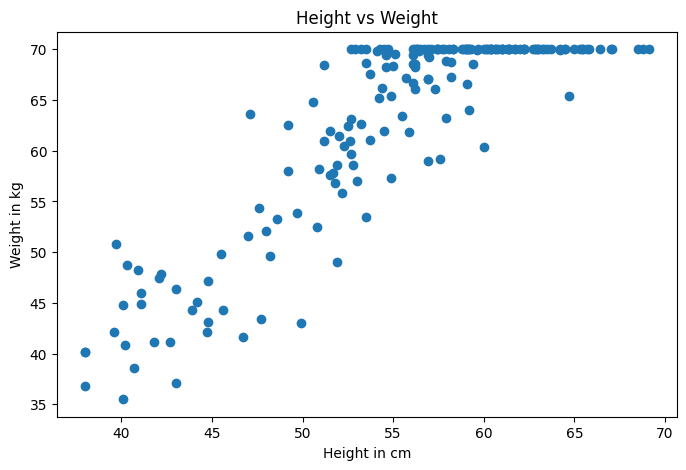

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["height_cm"], df["weight_kg"])
plt.xlabel("Height in cm")
plt.ylabel("Weight in kg")
plt.title("Height vs Weight")
plt.show()


## 5. Подготовка за Linear Regression

Ще използвам няколко входни features, за да предскажа `weight_kg`.


In [11]:
features = ["age_months", "height_cm", "activity_level", "sex_male"]
target = "weight_kg"

X = df[features]
y = df[target]


In [12]:
X.head()


,age_months,height_cm,activity_level,sex_male
0,54,61.4,5,1
1,17,45.5,5,0
2,74,64.5,3,1
3,63,60.3,4,1
4,23,54.4,2,1


In [13]:
y.head()


0    70.0
1    49.8
2    70.0
3    70.0
4    66.2
Name: weight_kg, dtype: float64

## 6. Train/Test split

Разделям данните на:
- training set — за обучение
- test set — за проверка


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 126
Test rows: 54


## 7. Обучаване на Linear Regression модел


In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print("Intercept:", round(linear_model.intercept_, 3))

for feature_name, coef in zip(features, linear_model.coef_):
    print(feature_name, "=>", round(coef, 3))


Intercept: 12.735
age_months => 0.143
height_cm => 0.773
activity_level => 0.179
sex_male => 2.019


## 8. Предсказване с Linear Regression


In [17]:
linear_predictions = linear_model.predict(X_test)
linear_predictions[:10]


array([68.34693786, 50.77369191, 47.12653997, 69.56420184, 56.18791634,
       74.39504245, 65.73582581, 76.59717287, 72.68040504, 55.57854434])

In [18]:
comparison = pd.DataFrame({
    "real_weight": y_test.values,
    "predicted_weight": linear_predictions.round(1)
})

comparison.head(10)


,real_weight,predicted_weight
0,66.1,68.3
1,43.1,50.8
2,44.9,47.1
3,70.0,69.6
4,49.0,56.2
5,70.0,74.4
6,70.0,65.7
7,70.0,76.6
8,70.0,72.7
9,64.8,55.6


## 9. Оценка на модела

Ще използвам:
- R² score
- MAE
- MSE


In [19]:
linear_r2 = r2_score(y_test, linear_predictions)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)

print("Linear Regression R²:", round(linear_r2, 3))
print("Linear Regression MAE:", round(linear_mae, 3), "kg")
print("Linear Regression MSE:", round(linear_mse, 3))


Linear Regression R²: 0.731
Linear Regression MAE: 4.528 kg
Linear Regression MSE: 25.565


## 10. Residuals

Residual = реална стойност - предсказана стойност.

Ако грешките са случайно разпръснати около 0, моделът изглежда по-добре.


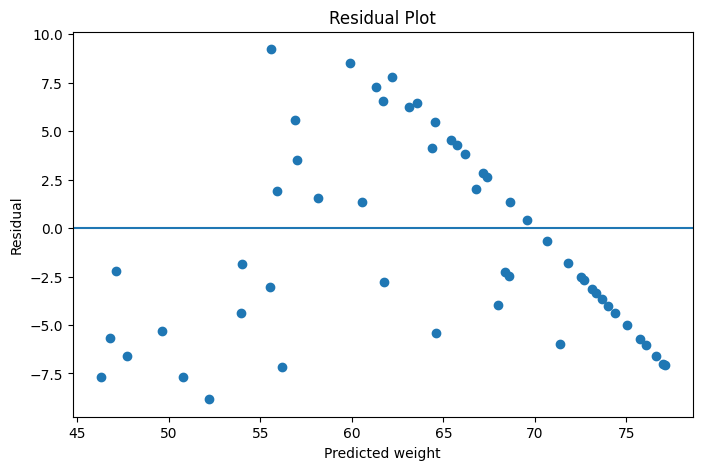

In [20]:
residuals = y_test - linear_predictions

plt.figure(figsize=(8, 5))
plt.scatter(linear_predictions, residuals)
plt.axhline(0)
plt.xlabel("Predicted weight")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


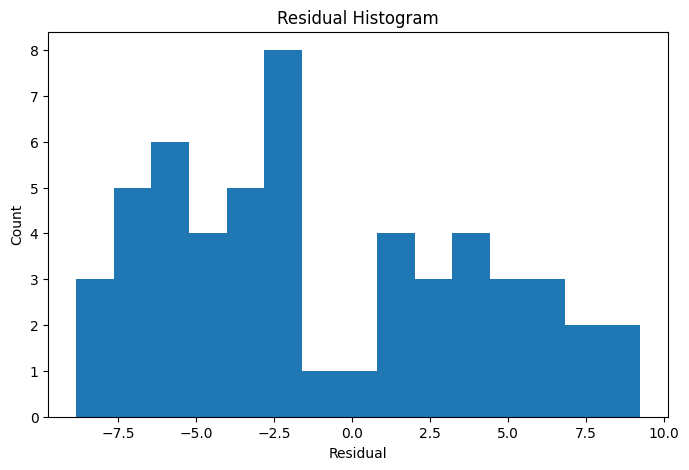

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Histogram")
plt.show()


## 11. Polynomial Regression

Понякога връзката не е напълно линейна.  
Polynomial Regression добавя степени като `x²`.


In [22]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


In [23]:
poly_model.fit(X_train, y_train)
poly_predictions = poly_model.predict(X_test)


In [24]:
print("Polynomial Regression R²:", round(r2_score(y_test, poly_predictions), 3))
print("Polynomial Regression MAE:", round(mean_absolute_error(y_test, poly_predictions), 3), "kg")
print("Polynomial Regression MSE:", round(mean_squared_error(y_test, poly_predictions), 3))


Polynomial Regression R²: 0.883
Polynomial Regression MAE: 2.43 kg
Polynomial Regression MSE: 11.118


## 12. Bias–Variance Tradeoff

Ще сравня няколко polynomial степени.

- Много ниска сложност може да даде underfitting.
- Много висока сложност може да даде overfitting.


In [25]:
degrees = [1, 2, 3, 5, 8]
degree_results = []

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    degree_results.append({
        "degree": degree,
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
        "test_MAE": mean_absolute_error(y_test, test_pred)
    })

pd.DataFrame(degree_results).round(3)


,degree,train_R2,test_R2,test_MAE
0,1,0.813,0.732,4.529
1,2,0.907,0.846,3.093
2,3,0.921,0.870,2.687
3,5,0.933,0.880,2.468
4,8,0.941,0.879,2.412


## 13. Regularization

Regularization помага моделът да не стане прекалено сложен.

Ще сравня:
- Linear Regression
- Ridge
- Lasso
- ElasticNet


In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.05, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000)
}


In [27]:
regularization_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    regularization_results.append({
        "model": name,
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds)
    })

pd.DataFrame(regularization_results).round(3)


,model,R2,MAE,MSE
0,Linear Regression,0.731,4.528,25.565
1,Ridge,0.732,4.529,25.549
2,Lasso,0.731,4.519,25.572
3,ElasticNet,0.732,4.524,25.524


## 14. Outliers

Outliers са необичайни точки в данните.

Ще добавя няколко грешни тегла, за да видя как влияят на модела.


In [28]:
df_outliers = df.copy()

outlier_rows = df_outliers.sample(8, random_state=7).index
df_outliers.loc[outlier_rows, "weight_kg"] += np.random.randint(18, 30, len(outlier_rows))

df_outliers.loc[outlier_rows]


,age_months,height_cm,activity_level,sex_male,weight_kg
138,61,67.1,5,1,88.0
36,53,57.4,1,1,89.0
169,34,51.2,4,1,88.4
143,64,54.7,2,0,88.0
126,53,56.5,1,1,96.0
133,31,58.3,5,1,95.0
102,75,57.9,1,0,82.2
32,53,64.2,5,1,96.0


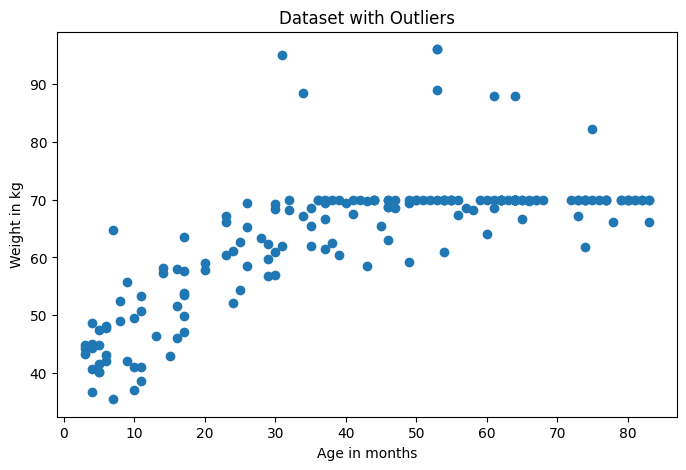

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df_outliers["age_months"], df_outliers["weight_kg"])
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Dataset with Outliers")
plt.show()


## 15. RANSAC Regression

RANSAC се опитва да намали влиянието на outliers.


In [30]:
X_out = df_outliers[features]
y_out = df_outliers[target]

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_out,
    y_out,
    test_size=0.30,
    random_state=42
)


In [31]:
normal_lr = LinearRegression()
normal_lr.fit(X_train_o, y_train_o)

normal_preds = normal_lr.predict(X_test_o)


In [32]:
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    random_state=42,
    min_samples=0.6,
    residual_threshold=8
)

ransac.fit(X_train_o, y_train_o)
ransac_preds = ransac.predict(X_test_o)


In [33]:
print("Linear Regression with outliers MAE:", round(mean_absolute_error(y_test_o, normal_preds), 3))
print("RANSAC with outliers MAE:", round(mean_absolute_error(y_test_o, ransac_preds), 3))


Linear Regression with outliers MAE: 5.956
RANSAC with outliers MAE: 5.725


## 16. Cross-Validation

Cross-validation прави няколко проверки вместо само една.

Така резултатът е по-надежден.


In [34]:
cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])


In [35]:
cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", np.round(cv_scores, 3))
print("Average CV R²:", round(cv_scores.mean(), 3))
print("CV standard deviation:", round(cv_scores.std(), 3))


CV R² scores: [0.799 0.831 0.781 0.659 0.779]
Average CV R²: 0.77
CV standard deviation: 0.059


## 17. Hyperparameter Tuning

Hyperparameters са настройки на модела.

При Ridge ще тествам различни стойности за `alpha`.


In [36]:
grid_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}


In [37]:
grid_search = GridSearchCV(
    grid_model,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [38]:
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)

print("Best alpha:", grid_search.best_params_["model__alpha"])
print("Best CV R²:", round(grid_search.best_score_, 3))
print("Final test R²:", round(r2_score(y_test, best_predictions), 3))
print("Final test MAE:", round(mean_absolute_error(y_test, best_predictions), 3), "kg")


Best alpha: 10
Best CV R²: 0.778
Final test R²: 0.733
Final test MAE: 4.513 kg


## 18. Feature Engineering

Feature engineering означава да създадем нови полезни features.

Ще добавя:
- `is_adult`
- `height_age_ratio`


In [39]:
df_fe = df.copy()

df_fe["is_adult"] = (df_fe["age_months"] >= 18).astype(int)
df_fe["height_age_ratio"] = df_fe["height_cm"] / (df_fe["age_months"] + 1)

df_fe.head()


,age_months,height_cm,activity_level,sex_male,weight_kg,is_adult,height_age_ratio
0,54,61.4,5,1,70.0,1,1.116364
1,17,45.5,5,0,49.8,0,2.527778
2,74,64.5,3,1,70.0,1,0.860000
3,63,60.3,4,1,70.0,1,0.942187
4,23,54.4,2,1,66.2,1,2.266667


In [40]:
features_fe = [
    "age_months",
    "height_cm",
    "activity_level",
    "sex_male",
    "is_adult",
    "height_age_ratio"
]

X_fe = df_fe[features_fe]
y_fe = df_fe[target]


In [41]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.30,
    random_state=42
)


In [42]:
fe_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

fe_model.fit(X_train_fe, y_train_fe)
fe_predictions = fe_model.predict(X_test_fe)


In [43]:
print("Feature Engineering Model R²:", round(r2_score(y_test_fe, fe_predictions), 3))
print("Feature Engineering Model MAE:", round(mean_absolute_error(y_test_fe, fe_predictions), 3), "kg")


Feature Engineering Model R²: 0.845
Feature Engineering Model MAE: 2.99 kg


## 19. Финално предсказание

Сега ще подам нов Cane Corso профил и моделът ще върне приблизително тегло.


In [44]:
new_cane = pd.DataFrame([{
    "age_months": 14,
    "height_cm": 58,
    "activity_level": 4,
    "sex_male": 1,
    "is_adult": 0,
    "height_age_ratio": 58 / (14 + 1)
}])

new_cane


,age_months,height_cm,activity_level,sex_male,is_adult,height_age_ratio
0,14,58,4,1,0,3.866667


In [45]:
predicted_weight = fe_model.predict(new_cane)[0]

print("Predicted approximate weight:", round(predicted_weight, 1), "kg")


Predicted approximate weight: 55.9 kg


## 20. Обобщение

В този notebook направих пълен Machine Learning пример:

1. Създадох примерни данни.
2. Разгледах данните визуално.
3. Разделих ги на train и test.
4. Обучих Linear Regression.
5. Измерих R², MAE и MSE.
6. Проверих residuals.
7. Пробвах Polynomial Regression.
8. Разгледах bias–variance.
9. Приложих regularization.
10. Демонстрирах RANSAC при outliers.
11. Направих cross-validation.
12. Използвах Grid Search.
13. Добавих feature engineering.
14. Направих финално предсказание.

Основната идея е:

**Данни → модел → обучение → тестване → оценка → подобрение.**
